# Lab | Natural Language Processing

## Complete Submission

This notebook presents an end-to-end Natural Language Processing workflow using Python and scikit-learn.

It covers:

- text cleaning and normalization;
- tokenization;
- stop-word removal;
- stemming;
- Bag of Words;
- TF-IDF;
- n-grams;
- text similarity;
- sentiment classification;
- model evaluation;
- feature interpretation.

The notebook is self-contained and does not require external downloads.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    CountVectorizer,
    TfidfVectorizer
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Create a small text corpus

The examples below use a small sentiment corpus so every exercise can run without relying on an external dataset.


In [2]:
data = pd.DataFrame({
    "text": [
        "I absolutely love this product, it works perfectly",
        "This is excellent and I am very happy",
        "The service was wonderful and friendly",
        "Fantastic experience, I would recommend it",
        "The quality is very good",
        "I enjoyed this movie a lot",
        "Amazing product and great value",
        "The result exceeded my expectations",
        "I am satisfied with my purchase",
        "Everything worked exactly as expected",
        "This was a pleasant surprise",
        "The staff were helpful and kind",
        "I hate this product, it is terrible",
        "This is awful and I am disappointed",
        "The service was horrible and rude",
        "Terrible experience, I would not recommend it",
        "The quality is very poor",
        "I disliked this movie",
        "Bad product and a waste of money",
        "The result failed my expectations",
        "I am dissatisfied with my purchase",
        "Nothing worked as expected",
        "This was an unpleasant experience",
        "The staff were unhelpful and unfriendly",
        "Really impressive performance and excellent quality",
        "A brilliant and enjoyable experience",
        "Very disappointing performance and poor quality",
        "A boring and frustrating experience",
        "I am extremely pleased with the service",
        "I am extremely unhappy with the service",
        "The product is reliable and useful",
        "The product is unreliable and useless"
    ],
    "sentiment": [
        "positive","positive","positive","positive",
        "positive","positive","positive","positive",
        "positive","positive","positive","positive",
        "negative","negative","negative","negative",
        "negative","negative","negative","negative",
        "negative","negative","negative","negative",
        "positive","positive","negative","negative",
        "positive","negative","positive","negative"
    ]
})

print("Dataset shape:", data.shape)
print("\nClass counts:")
print(data["sentiment"].value_counts())
data.head()

Dataset shape: (32, 2)

Class counts:
sentiment
positive    16
negative    16
Name: count, dtype: int64


,text,sentiment
0,"I absolutely love this product, it works perfe...",positive
1,This is excellent and I am very happy,positive
2,The service was wonderful and friendly,positive
3,"Fantastic experience, I would recommend it",positive
4,The quality is very good,positive


## 2. Normalize text

Typical preprocessing steps include:

1. convert text to lowercase;
2. remove URLs;
3. remove punctuation and digits;
4. collapse repeated whitespace.


In [3]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_text"] = data["text"].apply(normalize_text)

data[["text", "clean_text"]].head()

,text,clean_text
0,"I absolutely love this product, it works perfe...",i absolutely love this product it works perfectly
1,This is excellent and I am very happy,this is excellent and i am very happy
2,The service was wonderful and friendly,the service was wonderful and friendly
3,"Fantastic experience, I would recommend it",fantastic experience i would recommend it
4,The quality is very good,the quality is very good


## 3. Tokenization

Tokenization separates text into individual words or tokens.


In [4]:
def tokenize(text):
    return re.findall(r"\b[a-z]+\b", text.lower())

data["tokens"] = data["clean_text"].apply(tokenize)

data[["clean_text", "tokens"]].head()

,clean_text,tokens
0,i absolutely love this product it works perfectly,"[i, absolutely, love, this, product, it, works..."
1,this is excellent and i am very happy,"[this, is, excellent, and, i, am, very, happy]"
2,the service was wonderful and friendly,"[the, service, was, wonderful, and, friendly]"
3,fantastic experience i would recommend it,"[fantastic, experience, i, would, recommend, it]"
4,the quality is very good,"[the, quality, is, very, good]"


## 4. Remove stop words

Stop words are frequent words that often carry little discriminative information for classical text models.


In [5]:
stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words]

data["tokens_no_stopwords"] = data["tokens"].apply(remove_stopwords)

data[["tokens", "tokens_no_stopwords"]].head()

,tokens,tokens_no_stopwords
0,"[i, absolutely, love, this, product, it, works...","[absolutely, love, product, works, perfectly]"
1,"[this, is, excellent, and, i, am, very, happy]","[excellent, happy]"
2,"[the, service, was, wonderful, and, friendly]","[service, wonderful, friendly]"
3,"[fantastic, experience, i, would, recommend, it]","[fantastic, experience, recommend]"
4,"[the, quality, is, very, good]","[quality, good]"


## 5. Stemming

Stemming reduces words to shorter root-like forms.  
Here we use the Porter stemmer.


In [6]:
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

data["stemmed_tokens"] = data["tokens_no_stopwords"].apply(stem_tokens)

data[["tokens_no_stopwords", "stemmed_tokens"]].head()

,tokens_no_stopwords,stemmed_tokens
0,"[absolutely, love, product, works, perfectly]","[absolut, love, product, work, perfectli]"
1,"[excellent, happy]","[excel, happi]"
2,"[service, wonderful, friendly]","[servic, wonder, friendli]"
3,"[fantastic, experience, recommend]","[fantast, experi, recommend]"
4,"[quality, good]","[qualiti, good]"


## 6. Word-frequency analysis


In [7]:
all_tokens = [
    token
    for tokens in data["tokens_no_stopwords"]
    for token in tokens
]

frequency = Counter(all_tokens)

frequency_df = pd.DataFrame(
    frequency.most_common(15),
    columns=["word", "frequency"]
)

frequency_df

,word,frequency
0,product,6
1,experience,5
2,service,4
3,quality,4
4,excellent,2
5,recommend,2
6,movie,2
7,result,2
8,expectations,2
9,purchase,2


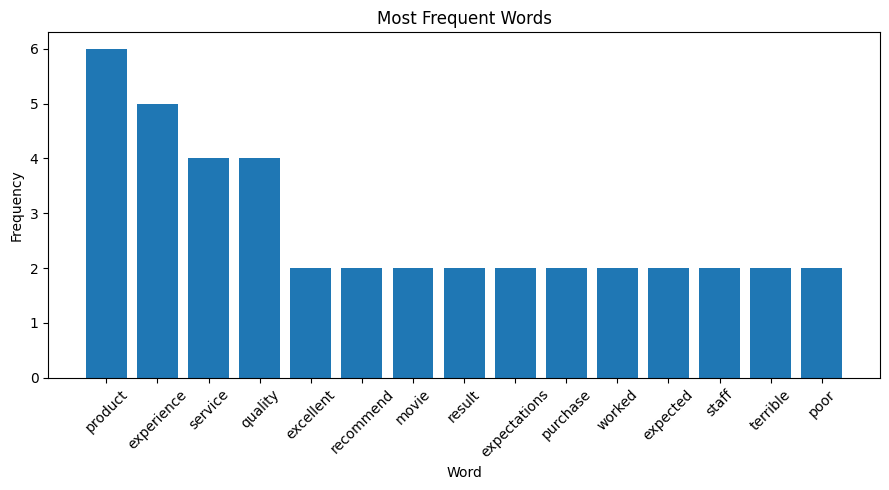

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(frequency_df["word"], frequency_df["frequency"])
plt.title("Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Bag of Words

Bag of Words turns documents into vectors containing word counts.


In [9]:
bow_vectorizer = CountVectorizer(
    stop_words="english"
)

bow_matrix = bow_vectorizer.fit_transform(data["clean_text"])

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Bag-of-Words shape:", bow_df.shape)
bow_df.head()

Bag-of-Words shape: (32, 65)


,absolutely,amazing,awful,bad,boring,brilliant,disappointed,disappointing,disliked,dissatisfied,...,unhelpful,unpleasant,unreliable,useful,useless,value,waste,wonderful,worked,works
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 8. N-grams

N-grams preserve short sequences of words.  
A bigram contains two consecutive terms.


In [10]:
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2)
)

bigram_matrix = bigram_vectorizer.fit_transform(data["clean_text"])

bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_counts
}).sort_values("count", ascending=False)

bigram_df.head(10)

,bigram,count
15,experience recommend,2
0,absolutely love,1
2,awful disappointed,1
1,amazing product,1
4,boring frustrating,1
5,brilliant enjoyable,1
6,disappointing performance,1
7,disliked movie,1
8,dissatisfied purchase,1
9,enjoyable experience,1


## 9. TF-IDF

TF-IDF gives more weight to words that are important in a particular document but less common across the complete corpus.


In [11]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(data["clean_text"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("TF-IDF shape:", tfidf_df.shape)
tfidf_df.head().round(3)

TF-IDF shape: (32, 125)


,absolutely,absolutely love,amazing,amazing product,awful,awful disappointed,bad,bad product,boring,boring frustrating,...,value,waste,waste money,wonderful,wonderful friendly,worked,worked exactly,worked expected,works,works perfectly
0,0.344,0.344,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.344,0.344
1,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.000
2,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.467,0.467,0.0,0.0,0.0,0.000,0.000
3,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.000
4,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.000


## 10. Cosine similarity

Cosine similarity compares the direction of document vectors.

- close to 1: very similar;
- close to 0: weak similarity.


In [12]:
example_documents = [
    "I love this excellent product",
    "This product is great and amazing",
    "The service was awful and terrible",
    "I dislike this bad product"
]

sim_vectorizer = TfidfVectorizer(stop_words="english")
sim_vectors = sim_vectorizer.fit_transform(example_documents)

sim_matrix = cosine_similarity(sim_vectors)

pd.DataFrame(
    sim_matrix,
    index=[f"doc_{i+1}" for i in range(len(example_documents))],
    columns=[f"doc_{i+1}" for i in range(len(example_documents))]
).round(3)

,doc_1,doc_2,doc_3,doc_4
doc_1,1.000,0.169,0.0,0.169
doc_2,0.169,1.000,0.0,0.169
doc_3,0.000,0.000,1.0,0.000
doc_4,0.169,0.169,0.0,1.000


## 11. Prepare data for supervised text classification

We will predict whether a sentence is positive or negative.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=data["sentiment"]
)

classifier_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = classifier_vectorizer.fit_transform(X_train)
X_test_tfidf = classifier_vectorizer.transform(X_test)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Feature count:", X_train_tfidf.shape[1])

Training samples: 24
Test samples: 8
Feature count: 101


## 12. Logistic Regression model


In [14]:
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(X_train_tfidf, y_train)

logistic_predictions = logistic_model.predict(X_test_tfidf)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression accuracy: {logistic_accuracy:.3f}")
print()
print(classification_report(y_test, logistic_predictions))

Logistic Regression accuracy: 0.250

              precision    recall  f1-score   support

    negative       0.25      0.25      0.25         4
    positive       0.25      0.25      0.25         4

    accuracy                           0.25         8
   macro avg       0.25      0.25      0.25         8
weighted avg       0.25      0.25      0.25         8



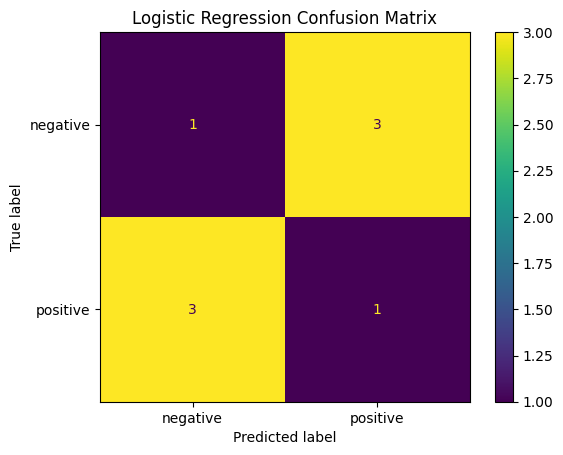

In [15]:
cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=["negative", "positive"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 13. Naive Bayes model

Multinomial Naive Bayes is a common classical baseline for text classification.


In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(f"Naive Bayes accuracy: {nb_accuracy:.3f}")
print()
print(classification_report(y_test, nb_predictions))

Naive Bayes accuracy: 0.250

              precision    recall  f1-score   support

    negative       0.25      0.25      0.25         4
    positive       0.25      0.25      0.25         4

    accuracy                           0.25         8
   macro avg       0.25      0.25      0.25         8
weighted avg       0.25      0.25      0.25         8



## 14. Compare the models


In [17]:
comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "accuracy": [
        logistic_accuracy,
        nb_accuracy
    ]
}).sort_values("accuracy", ascending=False)

comparison

,model,accuracy
0,Logistic Regression,0.25
1,Multinomial Naive Bayes,0.25


## 15. Interpret the Logistic Regression features

For a linear text classifier, coefficients indicate which terms are associated with each sentiment class.


In [18]:
feature_names = np.array(
    classifier_vectorizer.get_feature_names_out()
)

coef = logistic_model.coef_[0]

top_positive_indices = np.argsort(coef)[-10:][::-1]
top_negative_indices = np.argsort(coef)[:10]

print("Top positive features:")
for idx in top_positive_indices:
    print(f"{feature_names[idx]:<25} {coef[idx]:.3f}")

print("\nTop negative features:")
for idx in top_negative_indices:
    print(f"{feature_names[idx]:<25} {coef[idx]:.3f}")

Top positive features:
satisfied                 0.256
satisfied purchase        0.256
surprise                  0.233
pleasant surprise         0.233
pleasant                  0.233
exactly                   0.207
exactly expected          0.207
worked exactly            0.207
pleased service           0.207
extremely pleased         0.207

Top negative features:
worked expected           -0.274
dissatisfied              -0.254
dissatisfied purchase     -0.254
disliked movie            -0.251
disliked                  -0.251
poor                      -0.248
quality poor              -0.248
awful disappointed        -0.231
disappointed              -0.231
awful                     -0.231


## 16. Predict new sentences


In [19]:
new_sentences = [
    "The product is excellent and I really love it",
    "This was a terrible and disappointing experience",
    "The service was friendly and very helpful",
    "I would never recommend this awful product"
]

new_vectors = classifier_vectorizer.transform(new_sentences)

new_predictions = logistic_model.predict(new_vectors)

pd.DataFrame({
    "sentence": new_sentences,
    "predicted_sentiment": new_predictions
})

,sentence,predicted_sentiment
0,The product is excellent and I really love it,positive
1,This was a terrible and disappointing experience,negative
2,The service was friendly and very helpful,positive
3,I would never recommend this awful product,negative


## 17. Reusable preprocessing function


In [20]:
def preprocess_text(text, remove_stop_words=True, apply_stemming=False):
    clean = normalize_text(text)
    tokens = tokenize(clean)

    if remove_stop_words:
        tokens = remove_stopwords(tokens)

    if apply_stemming:
        tokens = stem_tokens(tokens)

    return tokens

example = "Natural Language Processing makes working with texts easier!"

print(preprocess_text(example))
print(preprocess_text(example, apply_stemming=True))

['natural', 'language', 'processing', 'makes', 'working', 'texts', 'easier']
['natur', 'languag', 'process', 'make', 'work', 'text', 'easier']


# Conclusions

This lab demonstrates the standard workflow for classical NLP:

1. **Normalize text** to reduce irrelevant variation.
2. **Tokenize** sentences into smaller language units.
3. Optionally remove **stop words** and apply **stemming**.
4. Convert text into numerical vectors using **Bag of Words** or **TF-IDF**.
5. Use **n-grams** when short word sequences are informative.
6. Compare text vectors with **cosine similarity**.
7. Train supervised models such as **Logistic Regression** or **Naive Bayes** for classification.
8. Evaluate the models using accuracy, classification reports, and confusion matrices.

TF-IDF with a linear classifier is a strong and interpretable baseline for many traditional text-classification problems.
